# Challenge 1: datos y análisis exploratorio

Tu primera responsabilidad es preparar una fuente de datos confiable para el proyecto de clasificación de vinos.

**Entrada:** `data/raw/wine.csv`  
**Salidas:** `data/processed/train.csv`, `data/processed/test.csv` y `artifacts/data_contract.json`

> El conjunto de test se crea aquí, pero no debe explorarse ni utilizarse después del split.

## Objetivos

- cargar y validar datos externos;
- identificar problemas básicos de calidad;
- crear un split reproducible y estratificado;
- realizar EDA únicamente sobre entrenamiento;
- guardar datos y metadatos para la siguiente etapa.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga y profiling

In [3]:
DATA_PATH = RAW_DATA_DIR / "wine.csv"

df = pd.read_csv(DATA_PATH)

TARGET = "target"
FEATURES = [column for column in df.columns if column != TARGET]
TARGET_NAMES = ["class_0", "class_1", "class_2"]

print("Archivo:", DATA_PATH.relative_to(PROJECT_DIR))
df.head()

Archivo: data\raw\wine.csv


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas predictoras: {len(FEATURES)}")
print("Duplicados:", df.duplicated().sum())
print("Valores faltantes:", int(df.isna().sum().sum()))

# Validaciones mínimas del esquema
assert TARGET in df.columns, "Falta la columna target"
assert df[FEATURES].select_dtypes(include="number").shape[1] == len(FEATURES), "Hay variables no numéricas"
assert set(df[TARGET].unique()) == {0, 1, 2}, "Clases inesperadas"

print("\nDistribución de la clase:")
class_distribution = pd.DataFrame({
    "n": df[TARGET].value_counts().sort_index(),
    "proporción": df[TARGET].value_counts(normalize=True).sort_index().round(3),
})
display(class_distribution)

profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
    "min": df.min(numeric_only=True),
    "max": df.max(numeric_only=True),
    "mean": df.mean(numeric_only=True).round(3),
    "std": df.std(numeric_only=True).round(3),
})
profile

Filas: 178
Columnas predictoras: 13
Duplicados: 0
Valores faltantes: 0

Distribución de la clase:


,n,proporción
target,,
0,59,0.331
1,71,0.399
2,48,0.270


,dtype,missing,unique,min,max,mean,std
alcohol,float64,0,126,11.03,14.83,13.001,0.812
malic_acid,float64,0,133,0.74,5.80,2.336,1.117
ash,float64,0,79,1.36,3.23,2.367,0.274
alcalinity_of_ash,float64,0,63,10.60,30.00,19.495,3.340
magnesium,float64,0,53,70.00,162.00,99.742,14.282
total_phenols,float64,0,97,0.98,3.88,2.295,0.626
flavanoids,float64,0,132,0.34,5.08,2.029,0.999
nonflavanoid_phenols,float64,0,39,0.13,0.66,0.362,0.124
proanthocyanins,float64,0,101,0.41,3.58,1.591,0.572
color_intensity,float64,0,132,1.28,13.00,5.058,2.318


**Conclusión de calidad:**

> El dataset tiene **178 vinos y 13 variables predictoras**, todas numéricas continuas (`float64`), y una variable objetivo `target` con 3 clases (0, 1, 2). **No hay valores faltantes ni filas duplicadas**, y los rangos son físicamente plausibles (sin negativos ni valores imposibles), así que **no fue necesario eliminar ni corregir registros**. Las clases están moderadamente desbalanceadas (33 % / 40 % / 27 %), por lo que **el split debe ser estratificado** y conviene reportar también F1 macro. Las variables tienen escalas muy distintas (`proline` va de 278 a 1680, mientras `hue` está entre 0.48 y 1.71), lo que habrá que tener en cuenta en el modelado. Por robustez, en la etapa de entrenamiento se incluirá igualmente un imputador dentro del pipeline, por si llegan datos nuevos con faltantes.

## 2. Split train/test

In [5]:
TEST_SIZE = 0.20

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["target"],
    random_state=RANDOM_STATE,
)

print("Proporciones por clase (train):", train_df["target"].value_counts(normalize=True).sort_index().round(3).to_dict())
print("Proporciones por clase (test): ", test_df["target"].value_counts(normalize=True).sort_index().round(3).to_dict())

Proporciones por clase (train): {0: 0.331, 1: 0.401, 2: 0.268}
Proporciones por clase (test):  {0: 0.333, 1: 0.389, 2: 0.278}


In [6]:
# Verificación del split
assert len(train_df) + len(test_df) == len(df)
assert set(train_df.index).isdisjoint(set(test_df.index))
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (142, 14)
Test: (36, 14)


## 3. EDA sobre entrenamiento

Incluye:

- distribución de clases;
- distribuciones o boxplots de variables relevantes;
- correlaciones;
- tres hallazgos que puedan influir en el modelado.

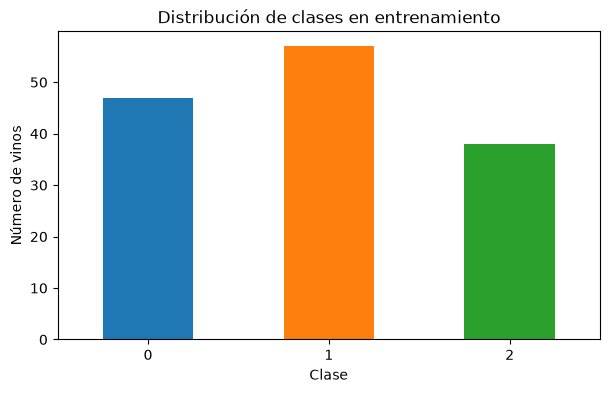

,ANOVA F
flavanoids,224.8
proline,161.5
od280/od315_of_diluted_wines,144.8
color_intensity,103.9
alcohol,98.5
hue,79.5
total_phenols,72.3
malic_acid,29.1
alcalinity_of_ash,27.5
proanthocyanins,23.3


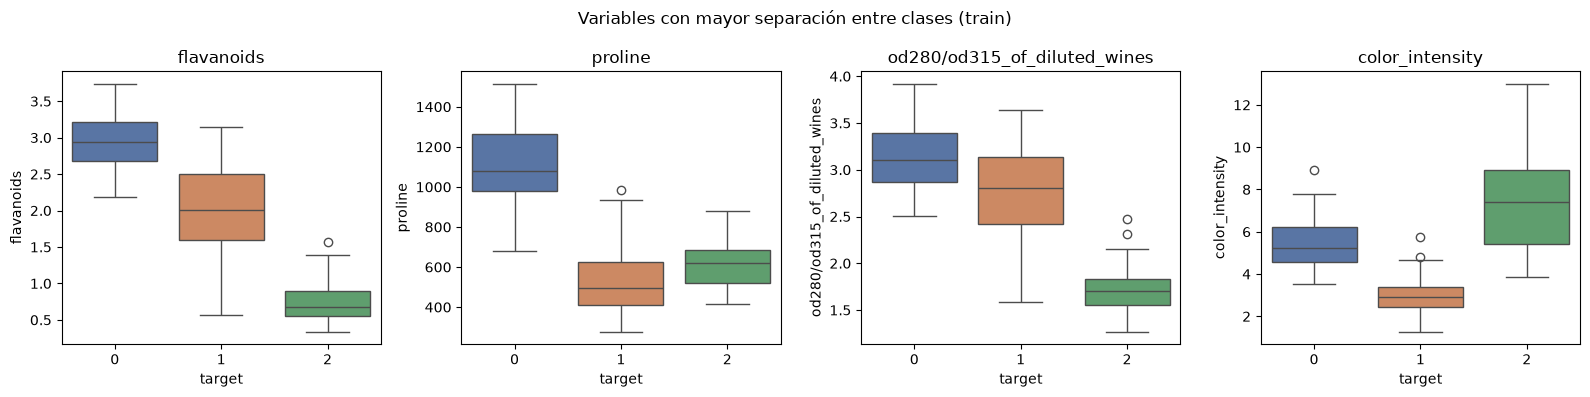

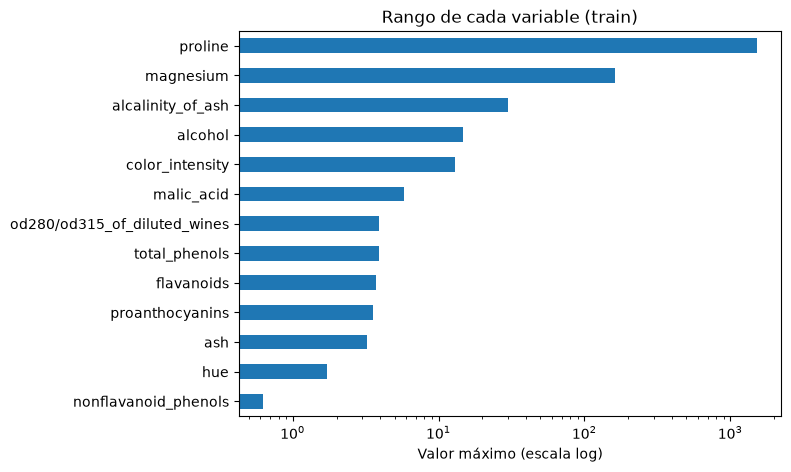

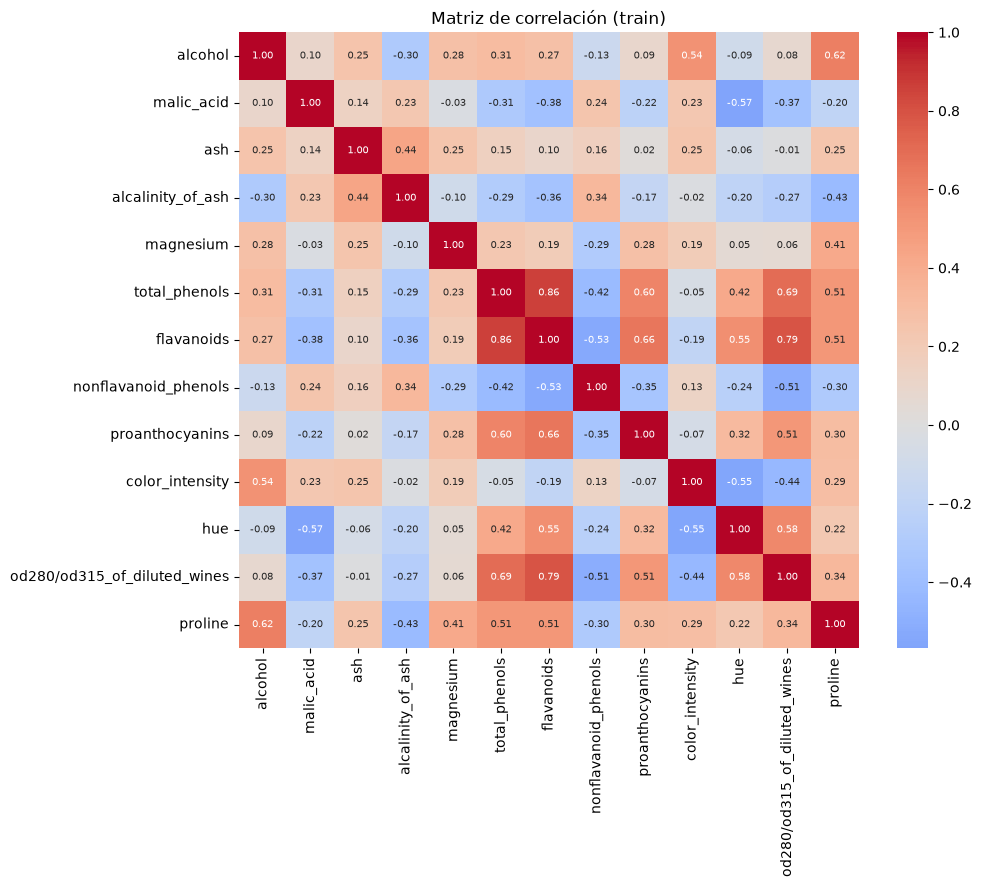

Pares más correlacionados:


,,|r|
total_phenols,flavanoids,0.861
flavanoids,od280/od315_of_diluted_wines,0.786
total_phenols,od280/od315_of_diluted_wines,0.695
flavanoids,proanthocyanins,0.657
alcohol,proline,0.621


In [7]:
# 1) Distribución de clases (solo train)
ax = train_df["target"].value_counts().sort_index().plot(kind="bar", color=sns.color_palette()[:3])
ax.set_xlabel("Clase")
ax.set_ylabel("Número de vinos")
ax.set_title("Distribución de clases en entrenamiento")
plt.xticks(rotation=0)
plt.show()

# 2) Variables más discriminantes: ranking por ANOVA F (solo train)
from sklearn.feature_selection import f_classif

f_scores, _ = f_classif(train_df[FEATURES], train_df["target"])
f_ranking = pd.Series(f_scores, index=FEATURES).sort_values(ascending=False)
display(f_ranking.round(1).to_frame("ANOVA F"))

top_features = f_ranking.index[:4].tolist()
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feature in zip(axes, top_features):
    sns.boxplot(data=train_df, x="target", y=feature, hue="target", palette="deep", legend=False, ax=ax)
    ax.set_title(feature)
plt.suptitle("Variables con mayor separación entre clases (train)")
plt.tight_layout()
plt.show()

# 3) Escalas muy distintas entre variables
train_df[FEATURES].describe().T[["mean", "std", "min", "max"]].sort_values("max").plot(
    kind="barh", y="max", logx=True, legend=False, figsize=(7, 5)
)
plt.xlabel("Valor máximo (escala log)")
plt.title("Rango de cada variable (train)")
plt.show()

# 4) Correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[FEATURES].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Matriz de correlación (train)")
plt.show()

corr = train_df[FEATURES].corr().abs()
pairs = (
    corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    .stack()
    .sort_values(ascending=False)
)
print("Pares más correlacionados:")
display(pairs.head(5).round(3).to_frame("|r|"))

**Hallazgos:**

1. **Hay variables muy discriminantes.** `flavanoids` (F ≈ 225), `proline` (F ≈ 162), `od280/od315` (F ≈ 145) y `color_intensity` (F ≈ 104) separan muy bien las clases. Por ejemplo, la clase 2 tiene flavonoides muy bajos (mediana ≈ 0.68 frente a 2.94 en la clase 0), la clase 0 tiene prolina muy alta (≈ 1080 frente a ≈ 500–620) y la clase 1 tiene poca intensidad de color (≈ 2.9). Esto sugiere que incluso modelos lineales simples pueden alcanzar un accuracy alto.
2. **Las escalas son muy diferentes** (prolina del orden de 10³, mientras `hue` o `nonflavanoid_phenols` son menores que 2). Para KNN, que se basa en distancias, y para Regresión Logística con regularización es **imprescindible estandarizar** dentro del pipeline; los árboles no lo necesitan.
3. **Hay multicolinealidad**: `total_phenols`–`flavanoids` (|r| = 0.86), `flavanoids`–`od280/od315` (0.79) y `alcohol`–`proline` (0.62). Estas variables aportan información redundante. Esto no afecta mucho la predicción, pero hace que los coeficientes de un modelo lineal sean menos interpretables individualmente, y justifica usar regularización (parámetro `C`). Además, con solo 142 ejemplos de entrenamiento la varianza entre folds será notable, así que conviene mirar la desviación estándar de la validación cruzada.

## 4. Persistencia de datos y contrato

In [8]:
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv(PROCESSED_DATA_DIR / "train.csv", index=False)
test_df.to_csv(PROCESSED_DATA_DIR / "test.csv", index=False)

import sklearn

contract = {
    "dataset": "Wine (UCI)",
    "target": TARGET,
    "target_names": TARGET_NAMES,
    "features": FEATURES,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "n_train": len(train_df),
    "n_test": len(test_df),
    "sklearn_version": sklearn.__version__,
}
(ARTIFACTS_DIR / "data_contract.json").write_text(
    json.dumps(contract, indent=2), encoding="utf-8"
)
print("Datos y contrato guardados.")

Datos y contrato guardados.


In [9]:
# Verificación de entrega
assert (PROCESSED_DATA_DIR / "train.csv").exists()
assert (PROCESSED_DATA_DIR / "test.csv").exists()
assert (ARTIFACTS_DIR / "data_contract.json").exists()
print("Challenge 1 completado.")

Challenge 1 completado.


## Checklist

- [x] Cargué el CSV desde `data/raw`.
- [x] Revisé calidad y distribución de la clase.
- [x] Realicé un split estratificado.
- [x] No exploré el conjunto de test.
- [x] Guardé los tres artefactos requeridos.